# 1 - Carregando Bibliotecas e Dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import optuna
import joblib

In [17]:
# Lendo o dataset diretamente do repositório do GitHub
df = pd.read_csv("https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv")

# 2 - Definição da variável target

Será utilizado o NPS como variável target e utilizaremos modelos de regressão

In [18]:
df['nps_score'].head()

0    6.9
1    2.4
2    4.8
3    5.9
4    6.1
Name: nps_score, dtype: float64

# 3 - Selecionando as features
Juntamente com a análise exploratória de dados, as features mais importantes foram identificadas, sendo elas:
1. complaints_count
2. delivery_delay_days
3. customer_service_contacts
4. resolution_time_days
5. csat_internal_score ->Descartaremos essa feature pois não é possível atuar nela com as informações disponíveis

In [19]:
columns2select= ['complaints_count', 'delivery_delay_days', 'customer_service_contacts', 'resolution_time_days', 'nps_score']

In [20]:
df_feat = df[columns2select]

# 3 - Separando em dataframes treino, teste e validação

In [21]:
X_train_test, X_val, y_train_test, y_val = train_test_split(df_feat.drop(columns=['nps_score']), df_feat['nps_score'], test_size=0.2, random_state=42)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=0.30, random_state=42)

# 4 - Seleção de Modelo

## 4.1 - Regressão Linear como modelo baseline

In [23]:
lr_model = LinearRegression(
    fit_intercept=True,  # Ajusta o intercepto se necessário
    copy_X=True,         # Copia os dados originais para segurança
    n_jobs=-1            # Usa todos os núcleos para treinamento mais rápido
)

In [24]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = lr_model.predict(X_test)

In [26]:
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

MAE: 1.3166
MAPE: 582495697200904.7500
RMSE: 1.6762
R²: 0.5793


MAPE não é uma métrica adequada devido à quantidade de zeros na variável target `nps_score`, portanto, iremos seguir apenas com MAE, RMSE e R²

## 4.2 - RandomForestRegressor

In [27]:
rf_model = RandomForestRegressor(
    n_estimators=200,            # Número de árvores - bom balanço entre performance e tempo
    max_depth=12,               # Profundidade máxima - evita overfitting
    min_samples_split=5,        # Mínimo de amostras para dividir nó - regularização
    min_samples_leaf=2,         # Mínimo de amostras em folha - regularização
    random_state=42,            # Reproducibilidade
    n_jobs=-1                   # Usar todos os processadores
)

In [28]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [29]:
y_pred_rf = rf_model.predict(X_test)

In [30]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"R²: {r2_score(y_test, y_pred_rf):.4f}")

MAE: 1.3800
RMSE: 1.7467
R²: 0.5431


## 4.3 - LGBMRegressor

In [31]:
lgbm_model = LGBMRegressor(
    objective='regression',    # Tarefa de regressão
    n_estimators=200,          # Mais árvores para estabilidade inicial
    learning_rate=0.05,        # Taxa de aprendizado conservadora
    max_depth=8,               # Limita complexidade para evitar overfitting
    num_leaves=31,             # Complexidade da árvore interna
    min_child_samples=20,      # Regularização em folhas
    subsample=0.8,             # Amostragem de linhas para robustez
    colsample_bytree=0.8,      # Amostragem de features por árvore
    random_state=42,           # Reprodutibilidade
    n_jobs=-1                  # Usa todos os núcleos
)

In [32]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41
[LightGBM] [Info] Number of data points in the train set: 1400, number of used features: 4
[LightGBM] [Info] Start training from score 4.411000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [33]:
y_pred_lgbm = lgbm_model.predict(X_test)

In [34]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_lgbm):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_lgbm):.4f}")
print(f"R²: {r2_score(y_test, y_pred_lgbm):.4f}")

MAE: 1.3136
RMSE: 1.6726
R²: 0.5810


## 4.4 - XGBoostRegressor

In [35]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',  # Tarefa de regressão
    n_estimators=200,              # Mais árvores para estabilidade
    max_depth=6,                   # Profundidade moderada para evitar overfitting
    learning_rate=0.05,            # Taxa de aprendizado conservadora
    subsample=0.8,                 # Amostragem de linhas para robustez
    colsample_bytree=0.8,          # Amostragem de features por árvore
    min_child_weight=1,            # Regularização em folhas
    gamma=0,                       # Regularização adicional
    random_state=42,               # Reproducibilidade
    n_jobs=-1                      # Usa todos os núcleos
)

In [36]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [37]:
y_pred_xgb = xgb_model.predict(X_test)

In [38]:
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_xgb):.4f}")
print(f"R²: {r2_score(y_test, y_pred_xgb):.4f}")

MAE: 1.3407
RMSE: 1.7292
R²: 0.5522


De início, observa-se um resultado surpreendentemente bom para o modelo de Regressão Linear, além disso, dentre os modelos desafiantes, observa-se melhor desempenho utilizando o modelo LightGBM. Em seguida, realizaremos a otimização deste modelo na tentativa de melhorar o desempenho.

# 5 - Modelagem

Otimizando o modelo LightGBM Regressor que foi escolhido como o melhor (com exceção da Regressão Linear)

In [39]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# Definir a função objetivo para o Optuna
def objective(trial):
    params = {
        'objective': 'regression',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    return mae  # Optuna minimiza por padrão

print("Função objetivo definida com sucesso!")

Função objetivo definida com sucesso!


In [40]:
# Criar o estudo de otimização
sampler = TPESampler(seed=42)
study = optuna.create_study(
    sampler=sampler,
    pruner=MedianPruner(),
    direction='minimize'
)

# Executar a otimização
print("Iniciando otimização com Optuna...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMelhor MAE encontrado: {study.best_value:.4f}")
print(f"Melhores parâmetros: {study.best_params}")

[I 2026-04-23 18:28:56,026] A new study created in memory with name: no-name-e1a4ba01-f4de-41e3-82a3-d1547a5d0e03


Iniciando otimização com Optuna...


Best trial: 0. Best value: 1.32608:   2%|▏         | 1/50 [00:00<00:05,  8.85it/s]

[I 2026-04-23 18:28:56,139] Trial 0 finished with value: 1.3260788009889657 and parameters: {'n_estimators': 250, 'max_depth': 15, 'learning_rate': 0.2198661886016101, 'num_leaves': 68, 'min_child_samples': 12, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998}. Best is trial 0 with value: 1.3260788009889657.


Best trial: 1. Best value: 1.30847:   6%|▌         | 3/50 [00:00<00:05,  8.67it/s]

[I 2026-04-23 18:28:56,256] Trial 1 finished with value: 1.3084709246200716 and parameters: {'n_estimators': 447, 'max_depth': 11, 'learning_rate': 0.2127137007610176, 'num_leaves': 21, 'min_child_samples': 49, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381}. Best is trial 1 with value: 1.3084709246200716.
[I 2026-04-23 18:28:56,299] Trial 2 finished with value: 1.3214071521295163 and parameters: {'n_estimators': 172, 'max_depth': 6, 'learning_rate': 0.09196843064490177, 'num_leaves': 62, 'min_child_samples': 24, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898}. Best is trial 1 with value: 1.3084709246200716.
[I 2026-04-23 18:28:56,328] Trial 3 finished with value: 1.3271679523018705 and parameters: {'n_estimators': 155, 'max_depth': 7, 'learning_rate': 0.11054219114481381, 'num_leaves': 56, 'min_child_samples': 41, 'subsample': 0.5998368910791798, 'colsample_bytree': 0.7571172192068059}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 1. Best value: 1.30847:  10%|█         | 5/50 [00:00<00:02, 15.62it/s]

[I 2026-04-23 18:28:56,387] Trial 4 finished with value: 1.345618606422099 and parameters: {'n_estimators': 337, 'max_depth': 4, 'learning_rate': 0.18265591071853007, 'num_leaves': 33, 'min_child_samples': 7, 'subsample': 0.9744427686266666, 'colsample_bytree': 0.9828160165372797}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 1. Best value: 1.30847:  14%|█▍        | 7/50 [00:00<00:02, 15.12it/s]

[I 2026-04-23 18:28:56,476] Trial 5 finished with value: 1.3177215310646986 and parameters: {'n_estimators': 424, 'max_depth': 7, 'learning_rate': 0.03020396208790878, 'num_leaves': 75, 'min_child_samples': 25, 'subsample': 0.5610191174223894, 'colsample_bytree': 0.7475884550556351}. Best is trial 1 with value: 1.3084709246200716.
[I 2026-04-23 18:28:56,525] Trial 6 finished with value: 1.3307505332032912 and parameters: {'n_estimators': 113, 'max_depth': 14, 'learning_rate': 0.07837521449840505, 'num_leaves': 73, 'min_child_samples': 19, 'subsample': 0.7600340105889054, 'colsample_bytree': 0.7733551396716398}. Best is trial 1 with value: 1.3084709246200716.
[I 2026-04-23 18:28:56,578] Trial 7 finished with value: 1.3557524873387008 and parameters: {'n_estimators': 174, 'max_depth': 15, 'learning_rate': 0.23276471418497324, 'num_leaves': 96, 'min_child_samples': 46, 'subsample': 0.7989499894055425, 'colsample_bytree': 0.9609371175115584}. Best is trial 1 with value: 1.3084709246200716.

Best trial: 1. Best value: 1.30847:  16%|█▌        | 8/50 [00:00<00:02, 15.12it/s]

[I 2026-04-23 18:28:56,620] Trial 8 finished with value: 1.3646802087023138 and parameters: {'n_estimators': 135, 'max_depth': 6, 'learning_rate': 0.01452295938425088, 'num_leaves': 46, 'min_child_samples': 22, 'subsample': 0.6356745158869479, 'colsample_bytree': 0.9143687545759647}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 1. Best value: 1.30847:  20%|██        | 10/50 [00:00<00:02, 16.24it/s]

[I 2026-04-23 18:28:56,694] Trial 9 finished with value: 1.342796523777675 and parameters: {'n_estimators': 243, 'max_depth': 7, 'learning_rate': 0.1632661288643163, 'num_leaves': 31, 'min_child_samples': 41, 'subsample': 0.5372753218398854, 'colsample_bytree': 0.9934434683002586}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 1. Best value: 1.30847:  20%|██        | 10/50 [00:00<00:02, 16.24it/s]

[I 2026-04-23 18:28:56,972] Trial 10 finished with value: 1.3221626079004452 and parameters: {'n_estimators': 492, 'max_depth': 12, 'learning_rate': 0.2908915961255718, 'num_leaves': 21, 'min_child_samples': 34, 'subsample': 0.9538323976412588, 'colsample_bytree': 0.5404438131869235}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 1. Best value: 1.30847:  24%|██▍       | 12/50 [00:01<00:04,  7.70it/s]

[I 2026-04-23 18:28:57,262] Trial 11 finished with value: 1.433093968242016 and parameters: {'n_estimators': 461, 'max_depth': 10, 'learning_rate': 0.00305305262961968, 'num_leaves': 87, 'min_child_samples': 32, 'subsample': 0.8566378150699113, 'colsample_bytree': 0.6461192327509933}. Best is trial 1 with value: 1.3084709246200716.
[I 2026-04-23 18:28:57,435] Trial 12 finished with value: 1.4242980549099797 and parameters: {'n_estimators': 401, 'max_depth': 10, 'learning_rate': 0.28143079946176996, 'num_leaves': 80, 'min_child_samples': 30, 'subsample': 0.8811321081835723, 'colsample_bytree': 0.6584399635185049}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 1. Best value: 1.30847:  28%|██▊       | 14/50 [00:01<00:04,  7.33it/s]

[I 2026-04-23 18:28:57,563] Trial 13 finished with value: 1.3683011824521112 and parameters: {'n_estimators': 416, 'max_depth': 12, 'learning_rate': 0.2123428113540736, 'num_leaves': 48, 'min_child_samples': 49, 'subsample': 0.502998668303767, 'colsample_bytree': 0.6525706471917982}. Best is trial 1 with value: 1.3084709246200716.


Best trial: 15. Best value: 1.30566:  32%|███▏      | 16/50 [00:01<00:05,  6.60it/s]

[I 2026-04-23 18:28:57,805] Trial 14 finished with value: 1.416554890966279 and parameters: {'n_estimators': 355, 'max_depth': 9, 'learning_rate': 0.12872398103618662, 'num_leaves': 97, 'min_child_samples': 16, 'subsample': 0.7035687346508274, 'colsample_bytree': 0.8441147559750997}. Best is trial 1 with value: 1.3084709246200716.
[I 2026-04-23 18:28:57,937] Trial 15 finished with value: 1.305661397421153 and parameters: {'n_estimators': 431, 'max_depth': 12, 'learning_rate': 0.05340570818977042, 'num_leaves': 80, 'min_child_samples': 38, 'subsample': 0.7003627739924363, 'colsample_bytree': 0.5834038510293894}. Best is trial 15 with value: 1.305661397421153.


Best trial: 16. Best value: 1.30414:  36%|███▌      | 18/50 [00:02<00:04,  6.52it/s]

[I 2026-04-23 18:28:58,098] Trial 16 finished with value: 1.3041361431569525 and parameters: {'n_estimators': 373, 'max_depth': 12, 'learning_rate': 0.06053215806722133, 'num_leaves': 83, 'min_child_samples': 41, 'subsample': 0.7023291490601911, 'colsample_bytree': 0.5888631240210741}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:58,253] Trial 17 finished with value: 1.3063068225132188 and parameters: {'n_estimators': 361, 'max_depth': 13, 'learning_rate': 0.05288719720904875, 'num_leaves': 86, 'min_child_samples': 37, 'subsample': 0.7057881429129401, 'colsample_bytree': 0.5860296058680126}. Best is trial 16 with value: 1.3041361431569525.


Best trial: 16. Best value: 1.30414:  40%|████      | 20/50 [00:02<00:04,  7.44it/s]

[I 2026-04-23 18:28:58,356] Trial 18 finished with value: 1.3280568839762046 and parameters: {'n_estimators': 294, 'max_depth': 13, 'learning_rate': 0.05194027365132685, 'num_leaves': 89, 'min_child_samples': 41, 'subsample': 0.803438170386144, 'colsample_bytree': 0.7053609669837879}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:58,467] Trial 19 finished with value: 1.3056992894669066 and parameters: {'n_estimators': 385, 'max_depth': 9, 'learning_rate': 0.05731785495601579, 'num_leaves': 80, 'min_child_samples': 37, 'subsample': 0.6971006258027869, 'colsample_bytree': 0.582027767988615}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:58,545] Trial 20 finished with value: 1.3095007100361824 and parameters: {'n_estimators': 500, 'max_depth': 11, 'learning_rate': 0.12847765316213414, 'num_leaves': 65, 'min_child_samples': 44, 'subsample': 0.6460710979954691, 'colsample_bytree': 0.5062750735091078}. Best is trial 16 with value: 1.3041361431569

Best trial: 16. Best value: 1.30414:  48%|████▊     | 24/50 [00:02<00:02, 11.07it/s]

[I 2026-04-23 18:28:58,609] Trial 21 finished with value: 1.3052087331096547 and parameters: {'n_estimators': 382, 'max_depth': 9, 'learning_rate': 0.0652508142086155, 'num_leaves': 80, 'min_child_samples': 36, 'subsample': 0.7108386949287571, 'colsample_bytree': 0.58125968590268}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:58,665] Trial 22 finished with value: 1.3050187570970648 and parameters: {'n_estimators': 324, 'max_depth': 11, 'learning_rate': 0.07988755053780552, 'num_leaves': 80, 'min_child_samples': 36, 'subsample': 0.736591235787346, 'colsample_bytree': 0.5669332578235152}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:58,728] Trial 23 finished with value: 1.3441765006946678 and parameters: {'n_estimators': 307, 'max_depth': 8, 'learning_rate': 0.08924825583908817, 'num_leaves': 100, 'min_child_samples': 28, 'subsample': 0.7501282862511909, 'colsample_bytree': 0.6812469497890213}. Best is trial 16 with value: 1.304136143156952

Best trial: 27. Best value: 1.30244:  54%|█████▍    | 27/50 [00:02<00:01, 12.01it/s]

[I 2026-04-23 18:28:58,824] Trial 25 finished with value: 1.3054483818722835 and parameters: {'n_estimators': 256, 'max_depth': 10, 'learning_rate': 0.11029868566701834, 'num_leaves': 72, 'min_child_samples': 44, 'subsample': 0.8322741678248236, 'colsample_bytree': 0.6145747066000313}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:58,951] Trial 26 finished with value: 1.3527837072014126 and parameters: {'n_estimators': 328, 'max_depth': 13, 'learning_rate': 0.07485053954244479, 'num_leaves': 56, 'min_child_samples': 34, 'subsample': 0.7287434107838674, 'colsample_bytree': 0.7088632909757311}. Best is trial 16 with value: 1.3041361431569525.
[I 2026-04-23 18:28:59,013] Trial 27 finished with value: 1.302437602606435 and parameters: {'n_estimators': 388, 'max_depth': 8, 'learning_rate': 0.14998810746826657, 'num_leaves': 83, 'min_child_samples': 29, 'subsample': 0.6358721977445875, 'colsample_bytree': 0.6246146575859395}. Best is trial 27 with value: 1.302437602606

Best trial: 31. Best value: 1.29644:  64%|██████▍   | 32/50 [00:03<00:01, 15.22it/s]

[I 2026-04-23 18:28:59,039] Trial 28 finished with value: 1.313271409334505 and parameters: {'n_estimators': 206, 'max_depth': 4, 'learning_rate': 0.15463343970774554, 'num_leaves': 93, 'min_child_samples': 30, 'subsample': 0.6687974205739219, 'colsample_bytree': 0.6339284618639598}. Best is trial 27 with value: 1.302437602606435.
[I 2026-04-23 18:28:59,100] Trial 29 finished with value: 1.2987055365735618 and parameters: {'n_estimators': 256, 'max_depth': 8, 'learning_rate': 0.13012189045586464, 'num_leaves': 70, 'min_child_samples': 27, 'subsample': 0.6052491163121418, 'colsample_bytree': 0.521665176558115}. Best is trial 29 with value: 1.2987055365735618.
[I 2026-04-23 18:28:59,164] Trial 30 finished with value: 1.316921216679061 and parameters: {'n_estimators': 269, 'max_depth': 8, 'learning_rate': 0.1873251897066031, 'num_leaves': 68, 'min_child_samples': 11, 'subsample': 0.6010587836949306, 'colsample_bytree': 0.5110021684815566}. Best is trial 29 with value: 1.2987055365735618.


Best trial: 34. Best value: 1.29596:  68%|██████▊   | 34/50 [00:03<00:01, 14.25it/s]

[I 2026-04-23 18:28:59,282] Trial 32 finished with value: 1.2986963499784614 and parameters: {'n_estimators': 218, 'max_depth': 8, 'learning_rate': 0.12180781311508193, 'num_leaves': 84, 'min_child_samples': 21, 'subsample': 0.5956434944533313, 'colsample_bytree': 0.5263960035444243}. Best is trial 31 with value: 1.2964442277340682.
[I 2026-04-23 18:28:59,369] Trial 33 finished with value: 1.3107032908862644 and parameters: {'n_estimators': 219, 'max_depth': 8, 'learning_rate': 0.1298601949912604, 'num_leaves': 74, 'min_child_samples': 19, 'subsample': 0.5904345774556196, 'colsample_bytree': 0.5354368037765898}. Best is trial 31 with value: 1.2964442277340682.
[I 2026-04-23 18:28:59,435] Trial 34 finished with value: 1.295964786006463 and parameters: {'n_estimators': 201, 'max_depth': 6, 'learning_rate': 0.10912616575112745, 'num_leaves': 68, 'min_child_samples': 24, 'subsample': 0.6190110915513846, 'colsample_bytree': 0.5120526650329809}. Best is trial 34 with value: 1.295964786006463

Best trial: 37. Best value: 1.2948:  76%|███████▌  | 38/50 [00:03<00:00, 14.95it/s] 

[I 2026-04-23 18:28:59,501] Trial 35 finished with value: 1.295358853340039 and parameters: {'n_estimators': 202, 'max_depth': 5, 'learning_rate': 0.11285733022562608, 'num_leaves': 58, 'min_child_samples': 25, 'subsample': 0.5558363871023778, 'colsample_bytree': 0.5205628931629848}. Best is trial 35 with value: 1.295358853340039.
[I 2026-04-23 18:28:59,557] Trial 36 finished with value: 1.3006258591927116 and parameters: {'n_estimators': 190, 'max_depth': 5, 'learning_rate': 0.11076658513916048, 'num_leaves': 59, 'min_child_samples': 23, 'subsample': 0.5509999871276297, 'colsample_bytree': 0.503578741171342}. Best is trial 35 with value: 1.295358853340039.
[I 2026-04-23 18:28:59,626] Trial 37 finished with value: 1.2948044192180517 and parameters: {'n_estimators': 223, 'max_depth': 6, 'learning_rate': 0.10657054545558793, 'num_leaves': 51, 'min_child_samples': 20, 'subsample': 0.5145126664832956, 'colsample_bytree': 0.5496434250368833}. Best is trial 37 with value: 1.2948044192180517.

Best trial: 37. Best value: 1.2948:  88%|████████▊ | 44/50 [00:03<00:00, 18.12it/s]

[I 2026-04-23 18:28:59,720] Trial 39 finished with value: 1.313052339896268 and parameters: {'n_estimators': 151, 'max_depth': 5, 'learning_rate': 0.10052881748393128, 'num_leaves': 48, 'min_child_samples': 14, 'subsample': 0.5008390520474229, 'colsample_bytree': 0.8349709745094414}. Best is trial 37 with value: 1.2948044192180517.
[I 2026-04-23 18:28:59,773] Trial 40 finished with value: 1.3129337828263938 and parameters: {'n_estimators': 111, 'max_depth': 6, 'learning_rate': 0.16976253631476246, 'num_leaves': 40, 'min_child_samples': 7, 'subsample': 0.5362411241086987, 'colsample_bytree': 0.5581097437959331}. Best is trial 37 with value: 1.2948044192180517.
[I 2026-04-23 18:28:59,831] Trial 41 finished with value: 1.2995854894691756 and parameters: {'n_estimators': 170, 'max_depth': 5, 'learning_rate': 0.09425773492898916, 'num_leaves': 53, 'min_child_samples': 25, 'subsample': 0.5668365383790523, 'colsample_bytree': 0.5477484120112917}. Best is trial 37 with value: 1.294804419218051

Best trial: 37. Best value: 1.2948:  96%|█████████▌| 48/50 [00:04<00:00, 18.36it/s]

[I 2026-04-23 18:28:59,956] Trial 44 finished with value: 1.2998999390584052 and parameters: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.10907731524550435, 'num_leaves': 36, 'min_child_samples': 11, 'subsample': 0.5225228418807549, 'colsample_bytree': 0.5009602042941467}. Best is trial 37 with value: 1.2948044192180517.
[I 2026-04-23 18:29:00,027] Trial 45 finished with value: 1.3015342006380057 and parameters: {'n_estimators': 182, 'max_depth': 7, 'learning_rate': 0.08423858580633356, 'num_leaves': 42, 'min_child_samples': 20, 'subsample': 0.5542785547830134, 'colsample_bytree': 0.5626124227464363}. Best is trial 37 with value: 1.2948044192180517.
[I 2026-04-23 18:29:00,057] Trial 46 finished with value: 1.3037215718750335 and parameters: {'n_estimators': 143, 'max_depth': 5, 'learning_rate': 0.1010843727779135, 'num_leaves': 52, 'min_child_samples': 25, 'subsample': 0.5700174998281733, 'colsample_bytree': 0.5336139183324584}. Best is trial 37 with value: 1.29480441921805

Best trial: 37. Best value: 1.2948: 100%|██████████| 50/50 [00:04<00:00, 11.96it/s]

[I 2026-04-23 18:29:00,163] Trial 48 finished with value: 1.321611098886472 and parameters: {'n_estimators': 269, 'max_depth': 4, 'learning_rate': 0.14320563214338608, 'num_leaves': 57, 'min_child_samples': 23, 'subsample': 0.5752146220674785, 'colsample_bytree': 0.8831828451601752}. Best is trial 37 with value: 1.2948044192180517.
[I 2026-04-23 18:29:00,206] Trial 49 finished with value: 1.3741061503741612 and parameters: {'n_estimators': 237, 'max_depth': 6, 'learning_rate': 0.1826369292750563, 'num_leaves': 29, 'min_child_samples': 14, 'subsample': 0.6621380354324472, 'colsample_bytree': 0.7710676715685145}. Best is trial 37 with value: 1.2948044192180517.

Melhor MAE encontrado: 1.2948
Melhores parâmetros: {'n_estimators': 223, 'max_depth': 6, 'learning_rate': 0.10657054545558793, 'num_leaves': 51, 'min_child_samples': 20, 'subsample': 0.5145126664832956, 'colsample_bytree': 0.5496434250368833}


In [41]:
# Treinar o modelo com os melhores parâmetros
best_params = study.best_params
best_params['objective'] = 'regression'
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

lgbm_best_model = LGBMRegressor(**best_params)
lgbm_best_model.fit(X_train, y_train)

# Fazer predições com o modelo otimizado
y_pred_best = lgbm_best_model.predict(X_test)

# Avaliar o modelo otimizado
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = root_mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("=== Resultados do Modelo Otimizado ===")
print(f"MAE: {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²: {r2_best:.4f}")

=== Resultados do Modelo Otimizado ===
MAE: 1.2948
RMSE: 1.6656
R²: 0.5846


In [42]:
# Comparar resultados antes e depois da otimização
comparison_df = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Modelo Inicial': [
        mean_absolute_error(y_test, y_pred_lgbm),
        root_mean_squared_error(y_test, y_pred_lgbm),
        r2_score(y_test, y_pred_lgbm)
    ],
    'Modelo Otimizado': [mae_best, rmse_best, r2_best]
})

comparison_df['Melhoria (%)'] = ((comparison_df['Modelo Inicial'] - comparison_df['Modelo Otimizado']) / 
                                  comparison_df['Modelo Inicial'] * 100)

print("\n=== Comparação: Modelo Inicial vs Modelo Otimizado ===")
print(comparison_df.to_string(index=False))


=== Comparação: Modelo Inicial vs Modelo Otimizado ===
Métrica  Modelo Inicial  Modelo Otimizado  Melhoria (%)
    MAE        1.313647          1.294804      1.434368
   RMSE        1.672632          1.665608      0.419927
     R²        0.581045          0.584556     -0.604295


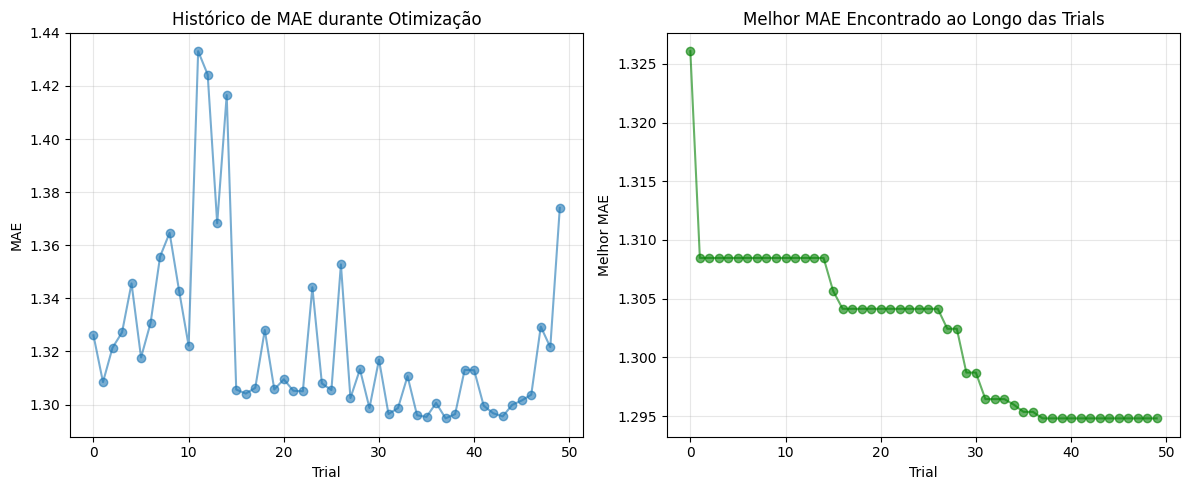

Total de trials executadas: 50


In [43]:
# Visualizar o histórico de otimização
trials_df = study.trials_dataframe()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trials_df.index, trials_df['value'], 'o-', alpha=0.6)
plt.xlabel('Trial')
plt.ylabel('MAE')
plt.title('Histórico de MAE durante Otimização')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(trials_df.index, trials_df['value'].cummin(), 'o-', color='green', alpha=0.6)
plt.xlabel('Trial')
plt.ylabel('Melhor MAE')
plt.title('Melhor MAE Encontrado ao Longo das Trials')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total de trials executadas: {len(trials_df)}")

In [44]:
# Exibir os melhores parâmetros encontrados
print("=== Melhores Parâmetros Encontrados ===")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

# Exibir importância dos parâmetros
print("\n=== Importância dos Parâmetros ===")
importances = optuna.importance.get_param_importances(study)
for key, value in sorted(importances.items(), key=lambda x: x[1], reverse=True):
    print(f"{key}: {value:.4f}")

=== Melhores Parâmetros Encontrados ===
n_estimators: 223
max_depth: 6
learning_rate: 0.10657054545558793
num_leaves: 51
min_child_samples: 20
subsample: 0.5145126664832956
colsample_bytree: 0.5496434250368833

=== Importância dos Parâmetros ===
colsample_bytree: 0.5129
learning_rate: 0.1724
n_estimators: 0.1282
num_leaves: 0.0889
subsample: 0.0484
min_child_samples: 0.0309
max_depth: 0.0182


## 5.1 - Comparando a performance do modelo otimizado com os outros modelos

In [45]:
# Compilar resultados de todos os modelos
results_dict = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    },
    'Random Forest': {
        'MAE': mean_absolute_error(y_test, y_pred_rf),
        'RMSE': root_mean_squared_error(y_test, y_pred_rf),
        'R²': r2_score(y_test, y_pred_rf)
    },
    'LGBM (Inicial)': {
        'MAE': mean_absolute_error(y_test, y_pred_lgbm),
        'RMSE': root_mean_squared_error(y_test, y_pred_lgbm),
        'R²': r2_score(y_test, y_pred_lgbm)
    },
    'XGBoost': {
        'MAE': mean_absolute_error(y_test, y_pred_xgb),
        'RMSE': root_mean_squared_error(y_test, y_pred_xgb),
        'R²': r2_score(y_test, y_pred_xgb)
    },
    'LGBM (Otimizado)': {
        'MAE': mae_best,
        'RMSE': rmse_best,
        'R²': r2_best
    }
}

# Converter para DataFrame
results_df = pd.DataFrame(results_dict).T
results_df = results_df.round(4)
print("=== Comparação de Performance de Todos os Modelos ===\n")
print(results_df)

=== Comparação de Performance de Todos os Modelos ===

                      MAE    RMSE      R²
Linear Regression  1.3166  1.6762  0.5793
Random Forest      1.3800  1.7467  0.5431
LGBM (Inicial)     1.3136  1.6726  0.5810
XGBoost            1.3407  1.7292  0.5522
LGBM (Otimizado)   1.2948  1.6656  0.5846


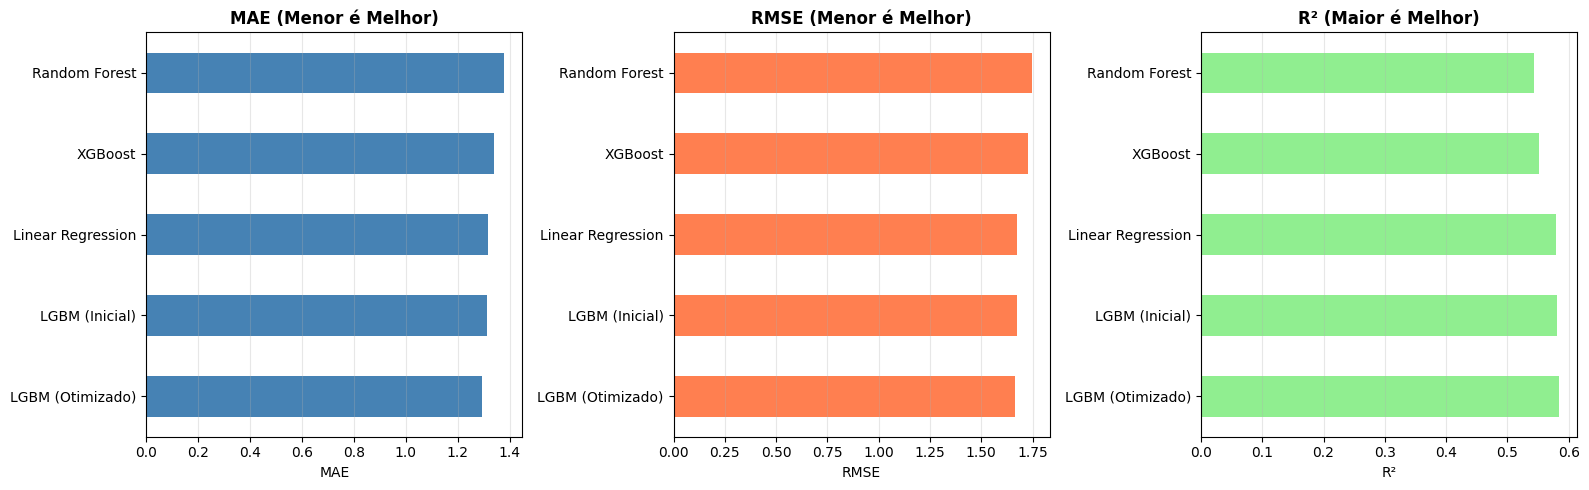

In [46]:
# Visualizar a comparação de MAE, RMSE e R² dos modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico de MAE
results_df['MAE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MAE (Menor é Melhor)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico de RMSE
results_df['RMSE'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RMSE (Menor é Melhor)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.3)

# Gráfico de R²
results_df['R²'].sort_values(ascending=False).plot(kind='barh', ax=axes[2], color='lightgreen')
axes[2].set_title('R² (Maior é Melhor)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5.2 - Calculando a importância das features no modelo otimizado

In [47]:
# Obter a importância
importances = lgbm_best_model.feature_importances_

# Criar um DataFrame para visualização
feature_imp = pd.DataFrame({'Value': importances, 'Feature': X_train.columns})
print(feature_imp.sort_values(by="Value", ascending=False))

   Value                    Feature
0   1644           complaints_count
2   1465  customer_service_contacts
3    921       resolution_time_days
1    535        delivery_delay_days


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

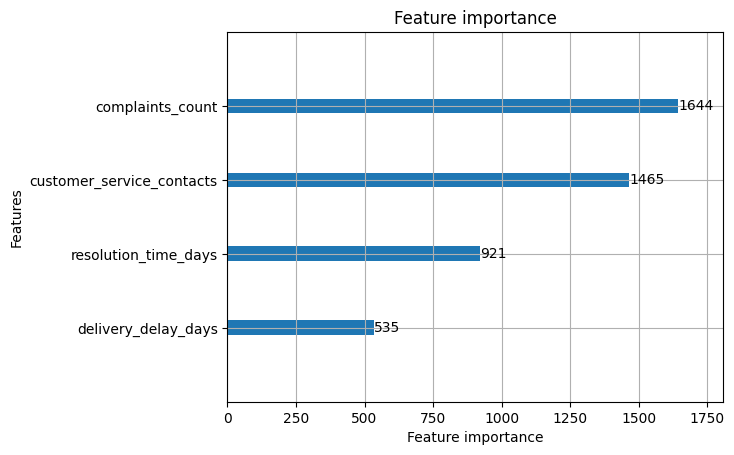

In [48]:
lgb.plot_importance(lgbm_best_model)

## 5.3 - Calculando os SHAP values para o modelo

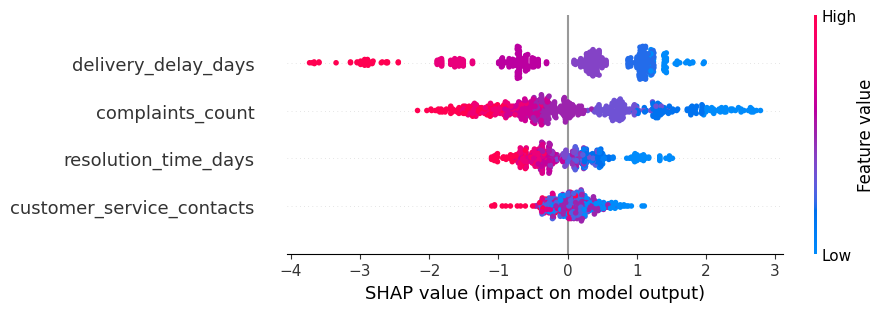

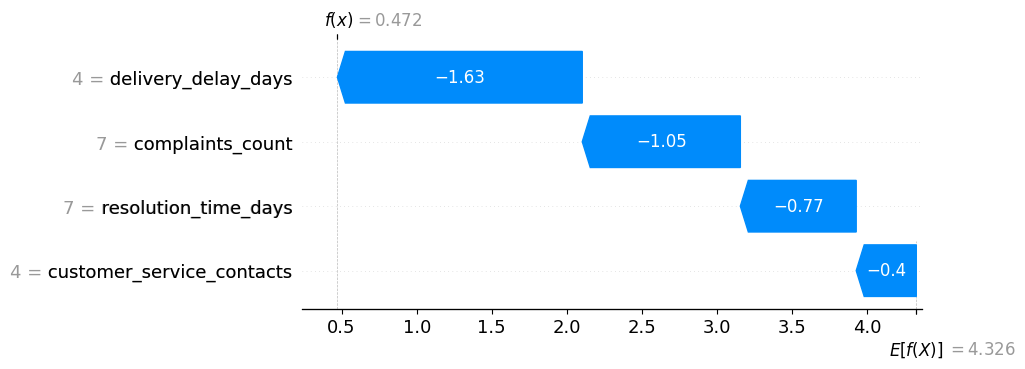

In [56]:
# 1. Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(lgbm_best_model, X_train)
shap_values = explainer(X_test)

# 2. Visualize the explanations
# Beeswarm plot for global interpretability
shap.plots.beeswarm(shap_values)

# Waterfall plot for a single prediction (e.g., first row)
shap.plots.waterfall(shap_values[0])

No primeiro gráfico (beeswarm), é possível observar a diferença de contribuição para o NPS de cada feature. Observa-se que, principalmente, as features `delivery_delay_days`, `complaints_count` e `resolution_time_days` possuem boa distinção entre seus valores baixos e altos e seus impactos no NPS.

# 6 - Validando o modelo

In [49]:
y_pred_val = lgbm_best_model.predict(X_val)

In [50]:
print(f"MAE: {mean_absolute_error(y_val, y_pred_val):.4f}")
print(f"RMSE: {root_mean_squared_error(y_val, y_pred_val):.4f}")
print(f"R²: {r2_score(y_val, y_pred_val):.4f}")

MAE: 1.3680
RMSE: 1.7146
R²: 0.5348


In [51]:
# Compilar resultados de todos os modelos
results_dict_val = {
    'LGBM (Otimizado)': {
        'MAE': mae_best,
        'RMSE': rmse_best,
        'R²': r2_best
    },
    'LGBM (Otimizado) - Validação': {
        'MAE': mean_absolute_error(y_val, y_pred_val),
        'RMSE': root_mean_squared_error(y_val, y_pred_val),
        'R²': r2_score(y_val, y_pred_val)
    }
}

# Converter para DataFrame
results_df_val = pd.DataFrame(results_dict_val).T
results_df_val = results_df_val.round(4)
print("=== Comparação de Performance de Todos os Modelos ===\n")
print(results_df_val)

=== Comparação de Performance de Todos os Modelos ===

                                 MAE    RMSE      R²
LGBM (Otimizado)              1.2948  1.6656  0.5846
LGBM (Otimizado) - Validação  1.3680  1.7146  0.5348


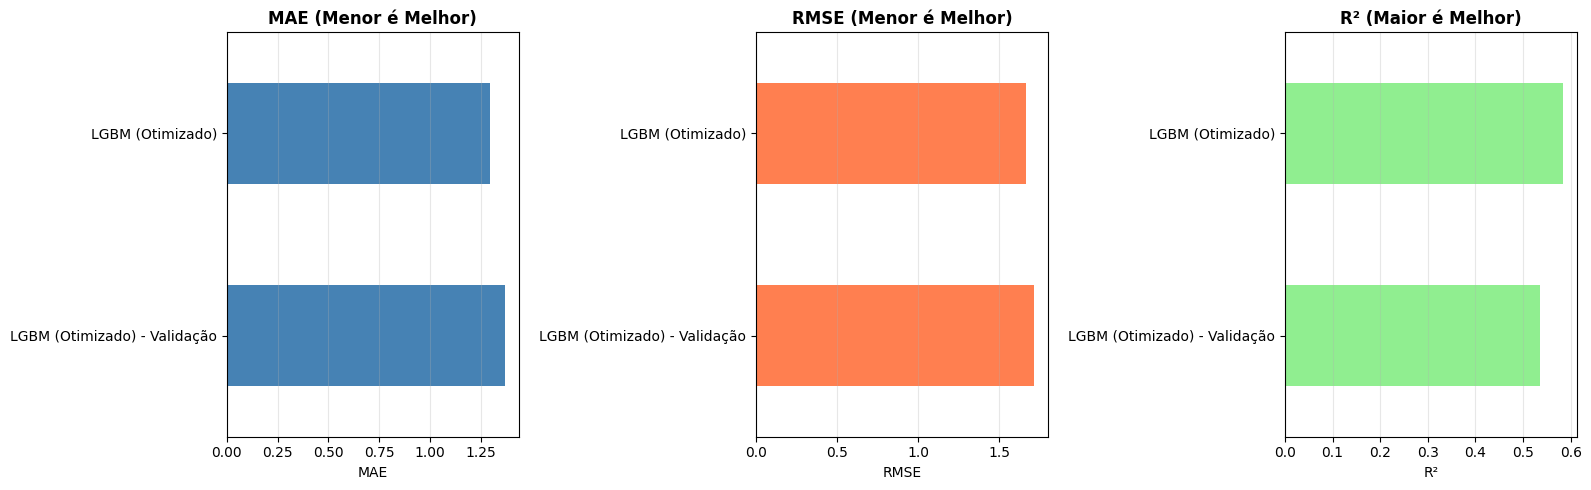

In [52]:
# Visualizar a comparação de MAE, RMSE e R² dos modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico de MAE
results_df_val['MAE'].sort_values(ascending=False).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MAE (Menor é Melhor)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico de RMSE
results_df_val['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RMSE (Menor é Melhor)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.3)

# Gráfico de R²
results_df_val['R²'].sort_values(ascending=True).plot(kind='barh', ax=axes[2], color='lightgreen')
axes[2].set_title('R² (Maior é Melhor)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 7 - Salvando o modelo otimizado para uso futuro

In [172]:
import joblib
import os
from datetime import datetime

# Criar diretório para modelos se não existir
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Gerar timestamp para versionamento
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Salvar o modelo otimizado com compressão
model_path = os.path.join(models_dir, f'lgbm_best_model_{timestamp}.joblib')
joblib.dump(lgbm_best_model, model_path, compress=3)
print(f"✓ Modelo salvo em: {model_path}")

# Salvar os melhores parâmetros em JSON
import json
params_path = os.path.join(models_dir, f'best_params_{timestamp}.json')
best_params_json = {k: v for k, v in best_params.items()}
with open(params_path, 'w') as f:
    json.dump(best_params_json, f, indent=4)
print(f"✓ Parâmetros salvos em: {params_path}")

# Salvar métricas do modelo
metrics_path = os.path.join(models_dir, f'model_metrics_{timestamp}.json')
metrics_dict = {
    'MAE': float(mae_best),
    'RMSE': float(rmse_best),
    'R²': float(r2_best),
    'timestamp': timestamp
}
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=4)
print(f"✓ Métricas salvas em: {metrics_path}")

# Exibir informações do arquivo salvo
file_size = os.path.getsize(model_path) / (1024 * 1024)  # Tamanho em MB
print(f"\n=== Resumo da Salva ===")
print(f"Tamanho do arquivo: {file_size:.2f} MB")
print(f"Compressão: Nível 3 (padrão)")
print(f"Timestamp: {timestamp}")

✓ Modelo salvo em: ../models\lgbm_best_model_20260422_231242.joblib
✓ Parâmetros salvos em: ../models\best_params_20260422_231242.json
✓ Métricas salvas em: ../models\model_metrics_20260422_231242.json

=== Resumo da Salva ===
Tamanho do arquivo: 0.13 MB
Compressão: Nível 3 (padrão)
Timestamp: 20260422_231242


# 8 - Carregando o modelo

In [33]:
import glob

# Listar todos os arquivos de modelo salvos
models_dir = '../models'
model_files = sorted(glob.glob(os.path.join(models_dir, 'lgbm_best_model_*.joblib')), reverse=True)

if model_files:
    # Carregar o modelo mais recente
    latest_model_path = model_files[0]
    loaded_model = joblib.load(latest_model_path)
    
    # Extrair timestamp do caminho
    model_timestamp = os.path.basename(latest_model_path).replace('lgbm_best_model_', '').replace('.joblib', '')
    
    # Carregar parâmetros
    params_file = os.path.join(models_dir, f'best_params_{model_timestamp}.json')
    with open(params_file, 'r') as f:
        loaded_params = json.load(f)
    
    # Carregar métricas
    metrics_file = os.path.join(models_dir, f'model_metrics_{model_timestamp}.json')
    with open(metrics_file, 'r') as f:
        loaded_metrics = json.load(f)
    
    # Exibir informações do modelo carregado
    print("=== Modelo Carregado com Sucesso ===")
    print(f"Arquivo: {os.path.basename(latest_model_path)}")
    print(f"Timestamp: {loaded_metrics['timestamp']}")
    print(f"\nMétricas do Modelo:")
    print(f"  MAE:  {loaded_metrics['MAE']:.4f}")
    print(f"  RMSE: {loaded_metrics['RMSE']:.4f}")
    print(f"  R²:   {loaded_metrics['R²']:.4f}")
    
    # Validar o modelo fazendo uma predição de teste
    test_pred = loaded_model.predict(X_test[:5])
    print(f"\nValidação: Predição em 5 amostras de teste")
    print(f"  Predições: {test_pred[:5]}")
    print(f"  Valores reais: {y_test.values[:5]}")
    print("\n✓ Modelo carregado e validado com sucesso!")
    
else:
    print("✗ Nenhum modelo encontrado na pasta ../models/")

=== Modelo Carregado com Sucesso ===
Arquivo: lgbm_best_model_20260422_231242.joblib
Timestamp: 20260422_231242

Métricas do Modelo:
  MAE:  1.2948
  RMSE: 1.6656
  R²:   0.5846


NameError: name 'X_test' is not defined

# 9 - Salvando parâmetros para modelo em produção

In [7]:
from pathlib import Path
import os
from dotenv import load_dotenv
from loguru import logger

# Load environment variables from .env file if it exists
load_dotenv()

# Paths
PROJ_ROOT = Path.cwd().resolve().parents[1] / "tech-challenge-01"
logger.info(f"PROJ_ROOT path is: {PROJ_ROOT}")

DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXTERNAL_DATA_DIR = DATA_DIR / "external"

MODELS_DIR = PROJ_ROOT / "models"

REPORTS_DIR = PROJ_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

python-dotenv could not parse statement starting at line 5
2026-04-23 18:01:13.258 | INFO     | __main__:<module>:11 - PROJ_ROOT path is: C:\Users\vinni\Documents\Projects\GitProjects\tech-challenge-01\tech-challenge-01


In [8]:
# Salva base de dados raw
df.to_csv(RAW_DATA_DIR / 'desafio_nps_fase_1.csv', index=False)

In [9]:
# Salva features para o modelo
feat_path = os.path.join(PROCESSED_DATA_DIR, 'features.joblib')
joblib.dump(columns2select, feat_path)
print(f"✓ Features salvas em: {feat_path}")

✓ Features salvas em: C:\Users\vinni\Documents\Projects\GitProjects\tech-challenge-01\tech-challenge-01\data\processed\features.joblib


In [13]:
# Carregar parâmetros
features = joblib.load(feat_path)

In [14]:
features

['complaints_count',
 'delivery_delay_days',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score']

In [16]:
MODELS_DIR

WindowsPath('c:/Users/vinni/Documents/Projects/GitProjects/tech-challenge-01/tech-challenge-01/notebooks/models')

In [19]:
import json

In [27]:
models_dir = '../models'
model_timestamp = '20240620_123456'
# Carregar parâmetros
params_file = os.path.join(models_dir, f'best_params_{model_timestamp}.json')
with open(params_file, 'r') as f:
    loaded_params = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../models\\best_params_20240620_123456.json'

In [21]:
json.loads('PROJ_ROOT/models/best_params_20240620_123456.json')

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [58]:
df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='str')